In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
import pathlib
import random
import math
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

In [5]:
# Your car dataset folder path in Google Drive
DATASET_PATH = "/content/drive/MyDrive/cardataset for ml"

data_dir = pathlib.Path(DATASET_PATH)

# Image size
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHANNELS = 3

# Hyperparameters
BATCH_SIZE = 16
EPOCHS = 10
LEARNING_RATE = 0.001

# For same train-test split every time
random.seed(42)
tf.random.set_seed(42)

print("Dataset exists:", data_dir.exists())
print("Folders available:")
print(os.listdir(DATASET_PATH))

Dataset exists: True
Folders available:
['Tesla', 'Maserati', 'Porsche', 'Kia', 'Rolls royce', 'Toyota', 'hyundai', 'Lexus', 'Ford mustang', 'Lamborghini', 'Benz', 'Ford', 'Bmw', 'Cadillac', 'Dodge', 'Ferrari', 'Audi', 'alfa romeo', 'Bentley']


In [6]:
CLASS_NAMES = sorted([
    item.name for item in data_dir.iterdir()
    if item.is_dir()
])

NUM_CLASSES = len(CLASS_NAMES)

# Convert Python list into TensorFlow constant
CLASS_NAMES_TF = tf.constant(CLASS_NAMES)

print("Car Classes:")
print(CLASS_NAMES)

print("\nNumber of car classes:", NUM_CLASSES)

Car Classes:
['Audi', 'Bentley', 'Benz', 'Bmw', 'Cadillac', 'Dodge', 'Ferrari', 'Ford', 'Ford mustang', 'Kia', 'Lamborghini', 'Lexus', 'Maserati', 'Porsche', 'Rolls royce', 'Tesla', 'Toyota', 'alfa romeo', 'hyundai']

Number of car classes: 19


In [7]:
IMAGE_EXTENSIONS = (
    "*.jpg", "*.jpeg", "*.png",
    "*.JPG", "*.JPEG", "*.PNG"
)

for class_name in CLASS_NAMES:
    class_folder = data_dir / class_name

    images = []

    for extension in IMAGE_EXTENSIONS:
        images.extend(list(class_folder.glob(extension)))

    print(class_name, ":", len(images), "images")

Audi : 0 images
Bentley : 688 images
Benz : 430 images
Bmw : 480 images
Cadillac : 646 images
Dodge : 627 images
Ferrari : 618 images
Ford : 629 images
Ford mustang : 734 images
Kia : 619 images
Lamborghini : 704 images
Lexus : 671 images
Maserati : 709 images
Porsche : 524 images
Rolls royce : 642 images
Tesla : 439 images
Toyota : 550 images
alfa romeo : 748 images
hyundai : 548 images


In [8]:
def read_and_decode(filename, resize_dims):

    # Read image file
    image_bytes = tf.io.read_file(filename)

    # Decode JPG, JPEG or PNG
    image = tf.image.decode_image(
        image_bytes,
        channels=IMG_CHANNELS,
        expand_animations=False
    )

    # Convert 0-255 pixels to 0-1 pixels
    image = tf.image.convert_image_dtype(image, tf.float32)

    # Resize every image into 224 x 224
    image = tf.image.resize(image, resize_dims)

    # Fix image shape
    image.set_shape([IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS])

    return image

In [9]:
def parse_csvline(csv_line):

    # CSV line format:
    # image_path,car_brand_name

    record_defaults = ["", ""]

    filename, label_string = tf.io.decode_csv(
        csv_line,
        record_defaults
    )

    # Read and prepare image
    image = read_and_decode(
        filename,
        [IMG_HEIGHT, IMG_WIDTH]
    )

    # Convert label name into number
    # Example: Audi -> 0, BMW -> 3, Tesla -> 15
    label = tf.argmax(
        tf.math.equal(CLASS_NAMES_TF, label_string),
        output_type=tf.int32
    )

    return image, label

In [10]:
TRAIN_CSV = "/tmp/car_train_set.csv"
EVAL_CSV = "/tmp/car_eval_set.csv"

train_rows = []
eval_rows = []

for class_name in CLASS_NAMES:

    class_folder = data_dir / class_name

    image_paths = []

    for extension in IMAGE_EXTENSIONS:
        image_paths.extend([
            str(path)
            for path in class_folder.glob(extension)
        ])

    # Shuffle images inside every class
    random.shuffle(image_paths)

    # 80% training and 20% validation
    split_index = math.ceil(len(image_paths) * 0.80)

    train_images = image_paths[:split_index]
    eval_images = image_paths[split_index:]

    for image_path in train_images:
        train_rows.append((image_path, class_name))

    for image_path in eval_images:
        eval_rows.append((image_path, class_name))


# Shuffle complete training and validation data
random.shuffle(train_rows)
random.shuffle(eval_rows)


# Write training CSV file
with open(TRAIN_CSV, "w") as file:

    for image_path, label in train_rows:
        file.write(f"{image_path},{label}\n")


# Write validation CSV file
with open(EVAL_CSV, "w") as file:

    for image_path, label in eval_rows:
        file.write(f"{image_path},{label}\n")


print("Training images:", len(train_rows))
print("Validation images:", len(eval_rows))

Training images: 8814
Validation images: 2192


In [11]:
train_dataset = (
    tf.data.TextLineDataset(TRAIN_CSV)

    .map(
        parse_csvline,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    .shuffle(
        buffer_size=min(len(train_rows), 1000)
    )

    .batch(BATCH_SIZE)

    .prefetch(tf.data.AUTOTUNE)
)


eval_dataset = (
    tf.data.TextLineDataset(EVAL_CSV)

    .map(
        parse_csvline,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    .batch(BATCH_SIZE)

    .prefetch(tf.data.AUTOTUNE)
)

In [12]:
for image_batch, label_batch in train_dataset.take(1):

    print("Image batch shape:", image_batch.shape)
    print("Label batch shape:", label_batch.shape)

    print("Labels:")
    print(label_batch.numpy())

Image batch shape: (16, 224, 224, 3)
Label batch shape: (16,)
Labels:
[ 7  1 11  7  1 10 16  6  5  9  4 10  7 11  4 18]


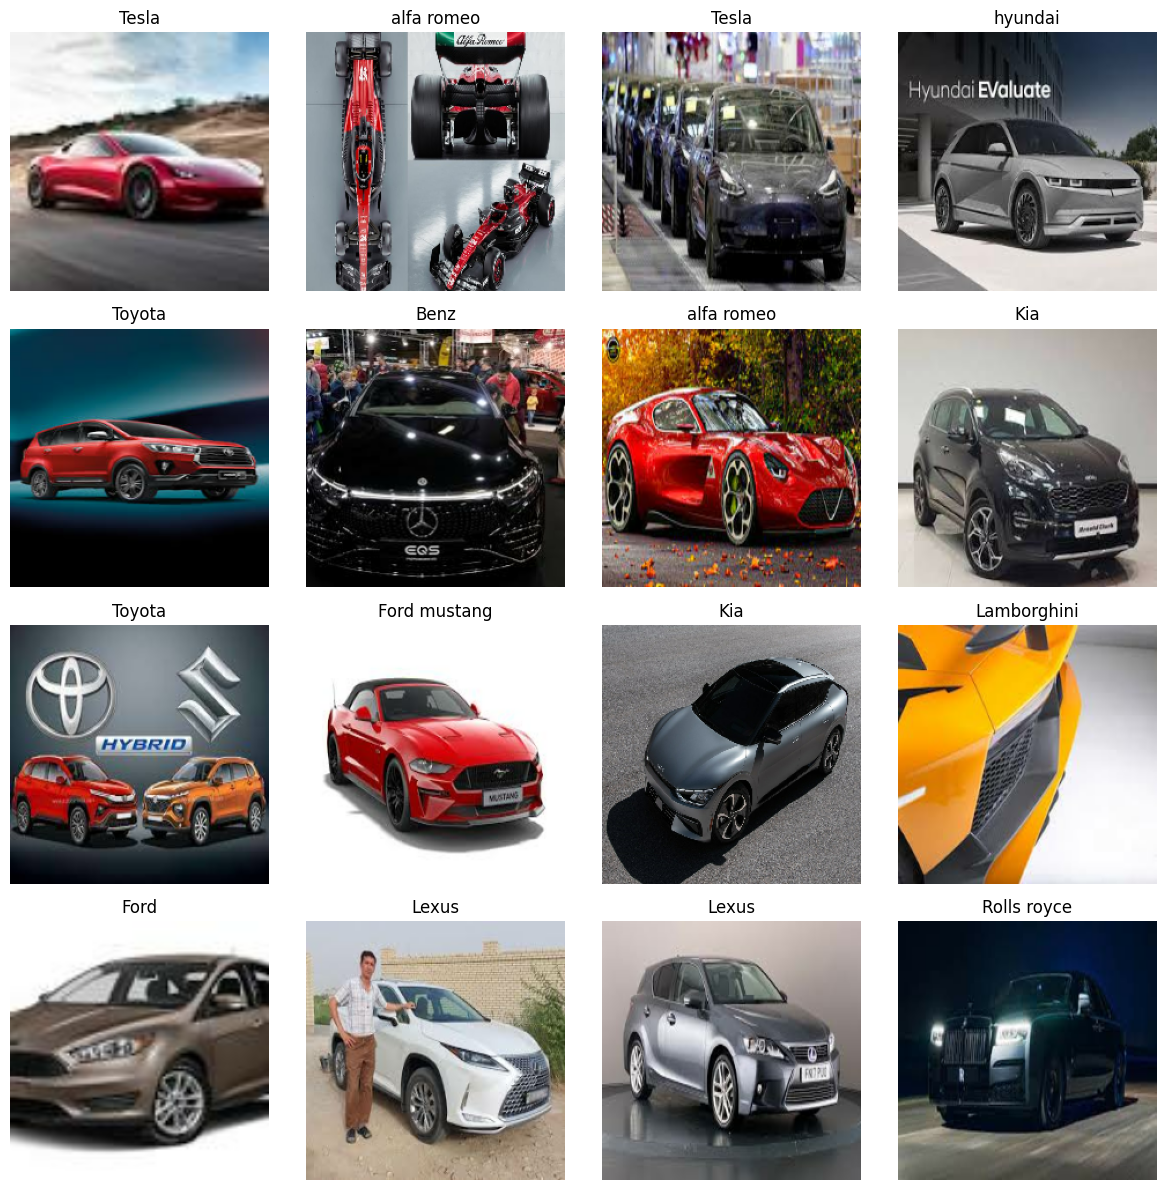

In [13]:
for image_batch, label_batch in train_dataset.take(1):

    plt.figure(figsize=(12, 12))

    display_count = min(16, image_batch.shape[0])

    for i in range(display_count):

        plt.subplot(4, 4, i + 1)

        plt.imshow(image_batch[i].numpy())

        plt.title(
            CLASS_NAMES[label_batch[i].numpy()]
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [14]:
model_linear = keras.Sequential([

    keras.layers.Input(
        shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)
    ),

    # Convert image matrix into one long vector
    keras.layers.Flatten(),

    # Hidden Layer 1
    # Default activation is linear
    keras.layers.Dense(128),

    # Hidden Layer 2
    # Default activation is linear
    keras.layers.Dense(64),

    # Output layer for all car classes
    keras.layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

In [15]:
model_linear.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

model_linear.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    19,267,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 19)             │         1,235 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,277,203 (73.54 MB)

 Trainable params: 19,277,203 (73.54 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
EPOCHS = 10

steps_per_epoch = math.ceil(
    len(train_rows) / BATCH_SIZE
)

history_linear = model_linear.fit(
    train_dataset,
    validation_data=eval_dataset,
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch
)

Epoch 1/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 102s 161ms/step - accuracy: 0.1980 - loss: 2.8957 - val_accuracy: 0.0940 - val_loss: 3.7822
Epoch 2/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 15s 28ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0940 - val_loss: 3.7822
Epoch 3/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 114s 188ms/step - accuracy: 0.1266 - loss: 17.9059 - val_accuracy: 0.0812 - val_loss: 12.4804
Epoch 4/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0812 - val_loss: 12.4804
Epoch 5/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 101s 166ms/step - accuracy: 0.1603 - loss: 3.5756 - val_accuracy: 0.1236 - val_loss: 3.1763
Epoch 6/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.1236 - val_loss: 3.1763
Epoch 7/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 203s 247ms/step - accuracy: 0.2033 - loss: 2.7751 - val_accuracy: 0.1131 - val_loss: 3.4143
Epoch 8/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step -

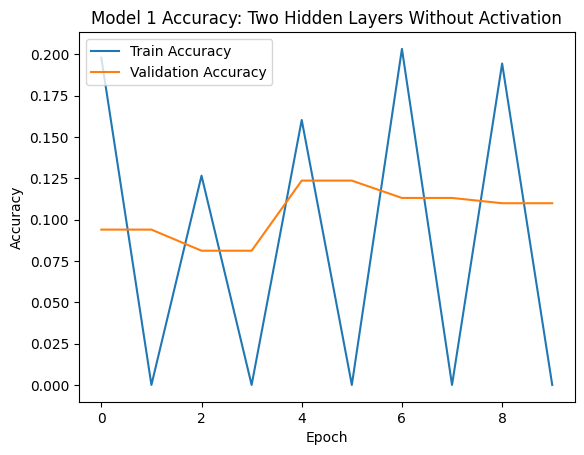

In [43]:
plt.plot(history_linear.history["accuracy"])
plt.plot(history_linear.history["val_accuracy"])

plt.legend([
    "Train Accuracy",
    "Validation Accuracy"
])

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Model 1 Accuracy: Two Hidden Layers Without Activation"
)

plt.show()

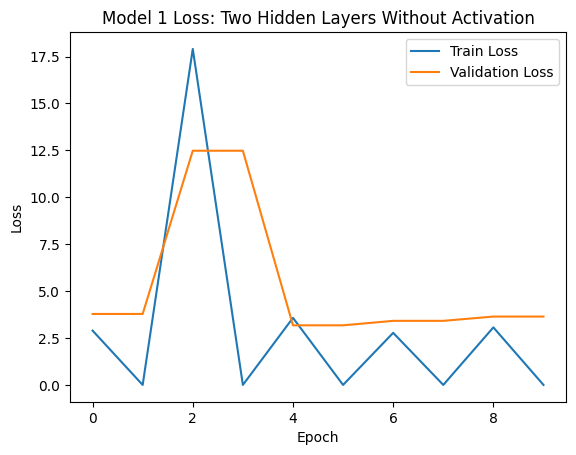

In [44]:
plt.plot(history_linear.history["loss"])
plt.plot(history_linear.history["val_loss"])

plt.legend([
    "Train Loss",
    "Validation Loss"
])

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Model 1 Loss: Two Hidden Layers Without Activation"
)

plt.show()

In [45]:
model_relu = keras.Sequential([

    keras.layers.Input(
        shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)
    ),

    # Convert image into one long vector
    keras.layers.Flatten(),

    # Hidden Layer 1 with ReLU activation
    keras.layers.Dense(
        128,
        activation="relu"
    ),

    # Hidden Layer 2 with ReLU activation
    keras.layers.Dense(
        64,
        activation="relu"
    ),

    # Output layer
    keras.layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

In [48]:
model_relu.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

model_relu.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │    19,267,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 19)             │         1,235 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,277,203 (73.54 MB)

 Trainable params: 19,277,203 (73.54 MB)

 Non-trainable params: 0 (0.00 B)

In [49]:
history_relu = model_relu.fit(

    train_dataset,

    validation_data=eval_dataset,

    epochs=EPOCHS
)

Epoch 1/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 100s 160ms/step - accuracy: 0.0675 - loss: 2.8797 - val_accuracy: 0.0680 - val_loss: 2.8784
Epoch 2/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 97s 157ms/step - accuracy: 0.0677 - loss: 2.8796 - val_accuracy: 0.0680 - val_loss: 2.8784
Epoch 3/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 97s 159ms/step - accuracy: 0.0632 - loss: 2.8795 - val_accuracy: 0.0680 - val_loss: 2.8784
Epoch 4/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 97s 159ms/step - accuracy: 0.0638 - loss: 2.8796 - val_accuracy: 0.0680 - val_loss: 2.8784
Epoch 5/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 98s 161ms/step - accuracy: 0.0641 - loss: 2.8795 - val_accuracy: 0.0680 - val_loss: 2.8783
Epoch 6/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 97s 159ms/step - accuracy: 0.0643 - loss: 2.8795 - val_accuracy: 0.0680 - val_loss: 2.8784
Epoch 7/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 137s 231ms/step - accuracy: 0.0636 - loss: 2.8795 - val_accuracy: 0.0680 - val_loss: 2.8783
Epoch 8/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 97s 159ms/step - accuracy: 0.0656 - loss:

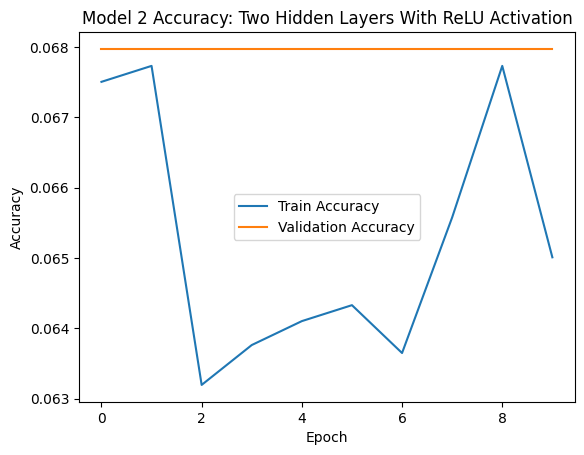

In [50]:
plt.plot(history_relu.history["accuracy"])
plt.plot(history_relu.history["val_accuracy"])

plt.legend([
    "Train Accuracy",
    "Validation Accuracy"
])

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Model 2 Accuracy: Two Hidden Layers With ReLU Activation"
)

plt.show()

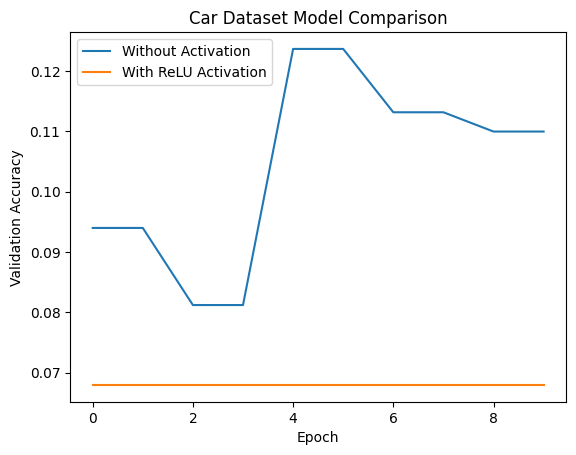

In [51]:
plt.plot(
    history_linear.history["val_accuracy"],
    label="Without Activation"
)

plt.plot(
    history_relu.history["val_accuracy"],
    label="With ReLU Activation"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")

plt.title("Car Dataset Model Comparison")

plt.legend()

plt.show()

In [52]:
best_linear_accuracy = max(
    history_linear.history["val_accuracy"]
)

best_relu_accuracy = max(
    history_relu.history["val_accuracy"]
)

print(
    "Best validation accuracy without activation:",
    round(best_linear_accuracy * 100, 2),
    "%"
)

print(
    "Best validation accuracy with ReLU:",
    round(best_relu_accuracy * 100, 2),
    "%"
)

Best validation accuracy without activation: 12.36 %
Best validation accuracy with ReLU: 6.8 %


In [53]:
print(
    "Model 1 total parameters:",
    model_linear.count_params()
)

print(
    "Model 2 total parameters:",
    model_relu.count_params()
)

Model 1 total parameters: 19277203
Model 2 total parameters: 19277203


In [55]:
hyperparameters = {

    "Image Height": IMG_HEIGHT,

    "Image Width": IMG_WIDTH,

    "Image Channels": IMG_CHANNELS,

    "Batch Size": BATCH_SIZE,

    "Epochs": EPOCHS,

    "Learning Rate": LEARNING_RATE,

    "Hidden Layer 1 Neurons": 128,

    "Hidden Layer 2 Neurons": 64,

    "Optimizer": "Adam",

    "Loss Function": "sparse_categorical_crossentropy",

    "Model 1 Hidden Activation": "Linear",

    "Model 2 Hidden Activation": "ReLU",

    "Output Activation": "Softmax"
}

for key, value in hyperparameters.items():

    print(key, ":", value)

Image Height : 224
Image Width : 224
Image Channels : 3
Batch Size : 16
Epochs : 10
Learning Rate : 0.001
Hidden Layer 1 Neurons : 128
Hidden Layer 2 Neurons : 64
Optimizer : Adam
Loss Function : sparse_categorical_crossentropy
Model 1 Hidden Activation : Linear
Model 2 Hidden Activation : ReLU
Output Activation : Softmax


In [56]:
flattened_input = IMG_HEIGHT * IMG_WIDTH * IMG_CHANNELS

first_hidden_layer_parameters = (
    flattened_input * 128
) + 128

second_hidden_layer_parameters = (
    128 * 64
) + 64

output_layer_parameters = (
    64 * NUM_CLASSES
) + NUM_CLASSES

total_parameters = (
    first_hidden_layer_parameters +
    second_hidden_layer_parameters +
    output_layer_parameters
)

print("Flattened input neurons:", flattened_input)

print(
    "Hidden Layer 1 parameters:",
    first_hidden_layer_parameters
)

print(
    "Hidden Layer 2 parameters:",
    second_hidden_layer_parameters
)

print(
    "Output Layer parameters:",
    output_layer_parameters
)

print(
    "Total parameters:",
    total_parameters
)

Flattened input neurons: 150528
Hidden Layer 1 parameters: 19267712
Hidden Layer 2 parameters: 8256
Output Layer parameters: 1235
Total parameters: 19277203


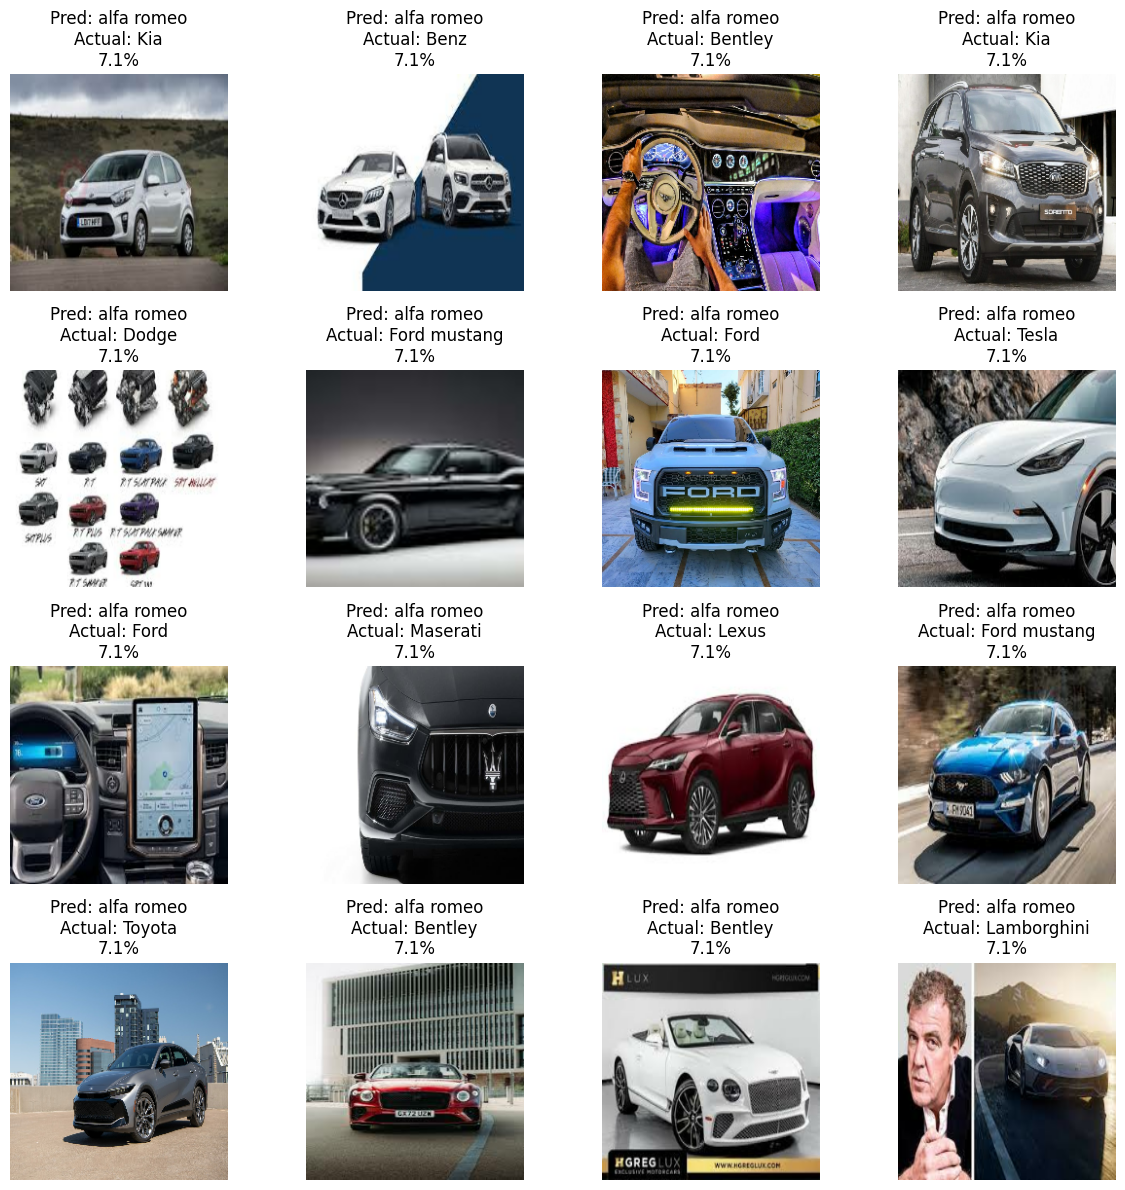

In [57]:
for images, labels in eval_dataset.take(1):

    predictions = model_relu.predict(
        images,
        verbose=0
    )

    predicted_indexes = np.argmax(
        predictions,
        axis=1
    )

    plt.figure(figsize=(12, 12))

    display_count = min(16, images.shape[0])

    for i in range(display_count):

        plt.subplot(4, 4, i + 1)

        plt.imshow(images[i].numpy())

        actual_class = CLASS_NAMES[
            labels[i].numpy()
        ]

        predicted_class = CLASS_NAMES[
            predicted_indexes[i]
        ]

        confidence = predictions[i][
            predicted_indexes[i]
        ] * 100

        plt.title(
            f"Pred: {predicted_class}\n"
            f"Actual: {actual_class}\n"
            f"{confidence:.1f}%"
        )

        plt.axis("off")

    plt.tight_layout()

    plt.show()